In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, binom
import math
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('default')
sns.set_palette('husl')


## problem 1: conditional probability

card stack has white and black cards. draw 2 cards without replacement.
given: P(white then black) = x, P(white first) = y
find: P(black | white first)

solution: P(black | white first) = x / y

In [2]:
def card_prob(x, y):
    if y == 0:
        return 0
    return x / y

print("problem 1: conditional probability")
test_cases = [(0.24, 0.6), (0.15, 0.5), (0.12, 0.4)]

for i, (x, y) in enumerate(test_cases, 1):
    result = card_prob(x, y)
    print(f"case {i}: x={x}, y={y}, result={result}")


problem 1: conditional probability
case 1: x=0.24, y=0.6, result=0.4
case 2: x=0.15, y=0.5, result=0.3
case 3: x=0.12, y=0.4, result=0.3



**Problem**: Test scores are normally distributed with mean m and standard deviation s.
Find the probability that a student passes with a cut-off of 90 marks.

**Solution**: P(X ≥ 90) = 1 - P(X < 90) = 1 - Φ((90 - m) / s)
where Φ is the standard normal CDF.

In [3]:
def normal_cutoff_probability(mean, std_dev, cutoff=90):
    z_score = (cutoff - mean) / std_dev
    prob_pass = 1 - norm.cdf(z_score)
    return round(prob_pass, 2)

test_cases = [
    (85, 10),   # mean=85, std=10
    (75, 15),   
    (95, 8),    
]

for i, (m, s) in enumerate(test_cases, 1):
    prob = normal_cutoff_probability(m, s)
    z_score = (90 - m) / s
    print(f"Test Case {i}:")
    print(f"  Mean (m) = {m}")
    print(f"  Standard Deviation (s) = {s}")
    print(f"  Z-score = ({90} - {m}) / {s} = {z_score:.3f}")
    print(f"  P(X ≥ 90) = {prob}")
    print()

def normal_probability_interactive():
    print("Enter distribution parameters:")
    m = float(input("Mean (m): "))
    s = float(input("Standard deviation (s): "))
    result = normal_cutoff_probability(m, s)
    print(f"\nProbability of passing (score ≥ 90): {result}")
    return result

# normal_probability_interactive()

Test Case 1:
  Mean (m) = 85
  Standard Deviation (s) = 10
  Z-score = (90 - 85) / 10 = 0.500
  P(X ≥ 90) = 0.31

Test Case 2:
  Mean (m) = 75
  Standard Deviation (s) = 15
  Z-score = (90 - 75) / 15 = 1.000
  P(X ≥ 90) = 0.16

Test Case 3:
  Mean (m) = 95
  Standard Deviation (s) = 8
  Z-score = (90 - 95) / 8 = -0.625
  P(X ≥ 90) = 0.73



## Problem 3: Circular Arrangement Probability

**Problem**: N people sit around a circular table. Find the probability that two particular people won't be sitting together.

**Solution**:
- Total arrangements in a circle: (N-1)!
- Arrangements where 2 people sit together: 2 × (N-2)!
- Arrangements where they don't sit together: (N-1)! - 2×(N-2)! = (N-3)×(N-2)!
- Probability = [(N-3)×(N-2)!] / [(N-1)!] = (N-3)/(N-1)

In [4]:
def circular_arrangement_probability(n):
    if n < 2:
        return 0.0  # Need at least 2 people
    if n == 2:
        return 0.0  # Two people will always sit together
    
    # Analytical solution: P = (n-3)/(n-1)
    probability = (n - 3) / (n - 1)
    return round(probability, 4)

# Calculate for various values of N
print("=== PROBLEM 3: CIRCULAR ARRANGEMENT ===\n")

test_values = [3, 4, 5, 6, 8, 10, 12, 20]

print("N\tP(not together)\tTotal arrangements\tTogether\tNot together")
print("-" * 70)

for n in test_values:
    prob = circular_arrangement_probability(n)
    total_arrangements = math.factorial(n - 1) if n > 0 else 0
    together_arrangements = 2 * math.factorial(n - 2) if n > 1 else 0
    not_together = total_arrangements - together_arrangements
    
    print(f"{n}\t{prob}\t\t{total_arrangements}\t\t{together_arrangements}\t\t{not_together}")

print("\nFormula: P(not together) = (N-3)/(N-1)")

# Interactive function
def circular_probability_interactive():
    print("\nEnter the number of people:")
    n = int(input("N: "))
    result = circular_arrangement_probability(n)
    print(f"\nProbability that two particular people won't sit together: {result}")
    return result

# circular_probability_interactive()

=== PROBLEM 3: CIRCULAR ARRANGEMENT ===

N	P(not together)	Total arrangements	Together	Not together
----------------------------------------------------------------------
3	0.0		2		2		0
4	0.3333		6		4		2
5	0.5		24		12		12
6	0.6		120		48		72
8	0.7143		5040		1440		3600
10	0.7778		362880		80640		282240
12	0.8182		39916800		7257600		32659200
20	0.8947		121645100408832000		12804747411456000		108840352997376000

Formula: P(not together) = (N-3)/(N-1)


## Problem 4: Central Limit Theorem with Dice Rolls

**Problem**: Roll a die 1 to 50 times, collect their sum. Repeat experiments multiple times (100, 500, 1000, 5000, 10000, 50000, 100000). Plot histograms and find mean and variance.

**Theory**: For n dice rolls, sum follows normal distribution with:
- Mean = n × 3.5
- Variance = n × (35/12) ≈ n × 2.917

In [5]:
def dice_clt():
    # settings
    max_dice = 50
    experiment_sizes = [100, 500, 1000, 5000, 10000, 50000, 100000]
    dice_counts = [1, 2, 3, 5, 10, 20, 30, 50]
    
    # die basics
    die_mean = 3.5
    die_variance = 35/12
    
    results = {}
    
    print("dice rolling experiments...")
    
    for n_dice in dice_counts:
        print(f"doing {n_dice} dice...")
        results[n_dice] = {}
        
        # theory values
        theoretical_mean = n_dice * die_mean
        theoretical_var = n_dice * die_variance
        
        for n_experiments in experiment_sizes:
            # simulate 
            sums = []
            for _ in range(n_experiments):
                dice_rolls = np.random.randint(1, 7, n_dice)
                sums.append(np.sum(dice_rolls))
            
            # stats
            observed_mean = np.mean(sums)
            observed_var = np.var(sums, ddof=1)
            
            results[n_dice][n_experiments] = {
                'sums': sums,
                'mean': observed_mean,
                'variance': observed_var,
                'theoretical_mean': theoretical_mean,
                'theoretical_var': theoretical_var
            }
    
    return results

# run it
dice_results = dice_clt()
print("done!")

dice rolling experiments...
doing 1 dice...
doing 2 dice...
doing 3 dice...
doing 5 dice...
doing 10 dice...
doing 20 dice...
doing 30 dice...
doing 50 dice...
done!


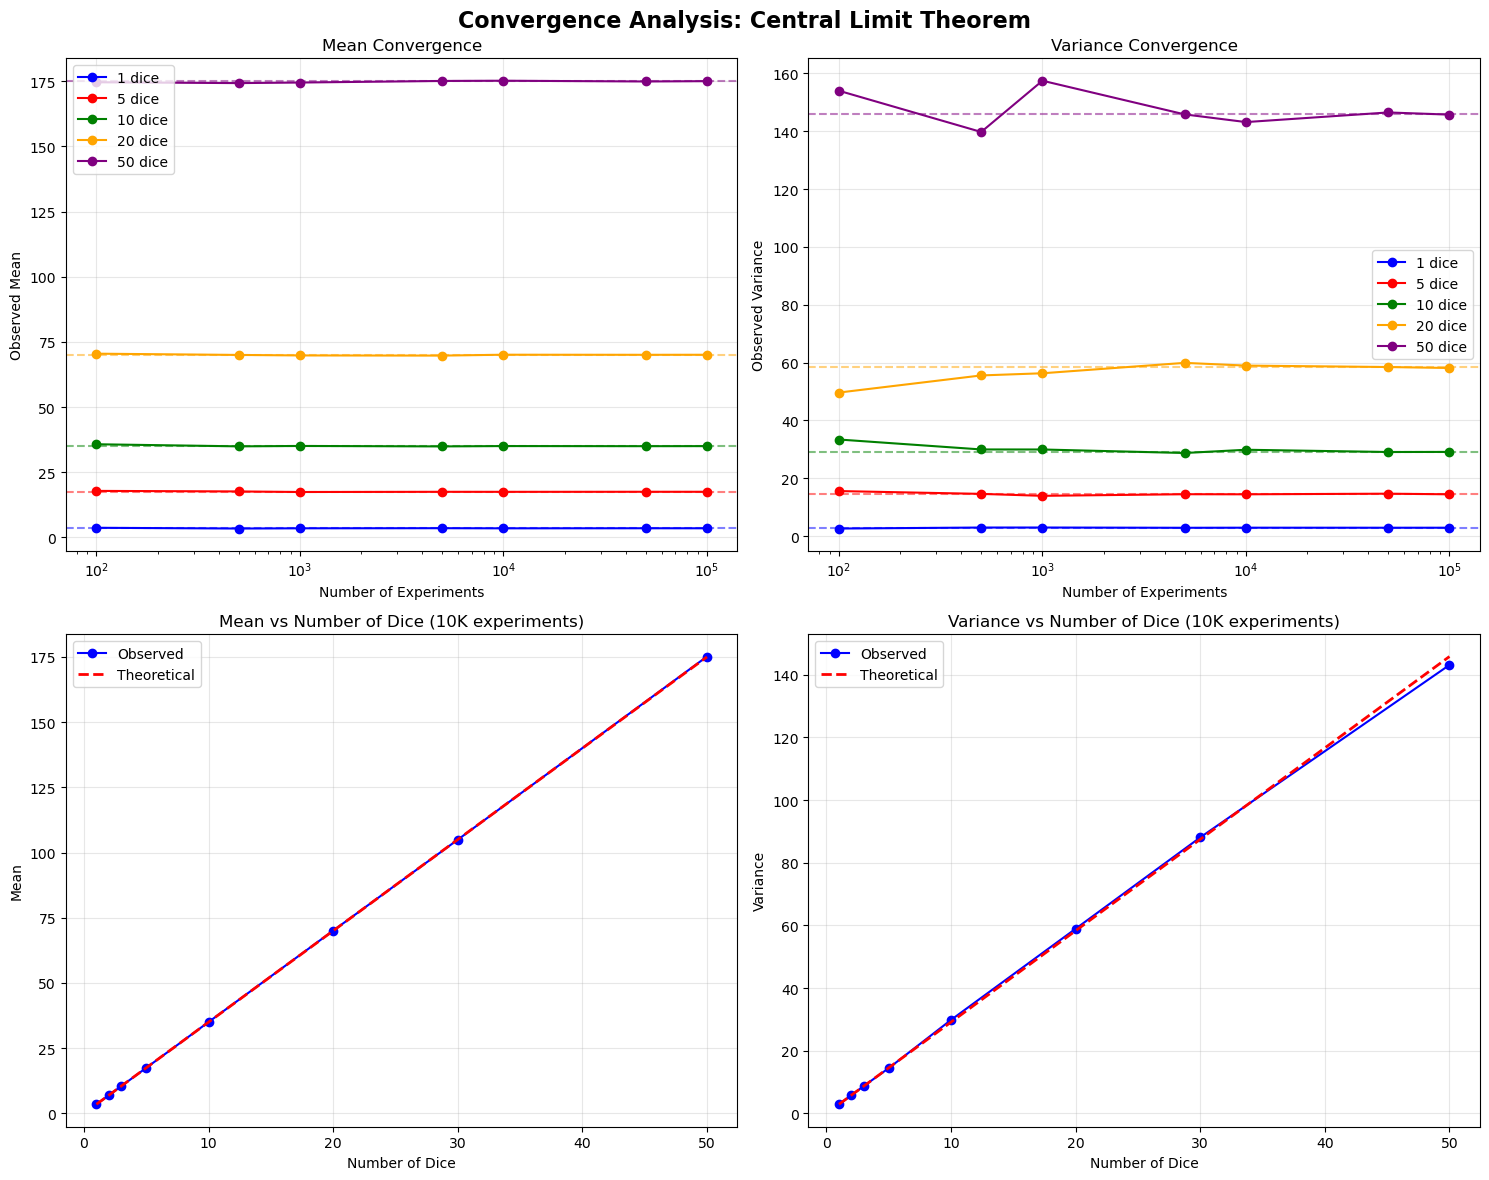

In [6]:
def analyze_convergence(results):
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Convergence Analysis: Central Limit Theorem', fontsize=16, fontweight='bold')
    
    experiment_sizes = [100, 500, 1000, 5000, 10000, 50000, 100000]
    dice_counts = [1, 5, 10, 20, 50]
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    # Plot 1: Mean convergence
    for i, n_dice in enumerate(dice_counts):
        means = [results[n_dice][n_exp]['mean'] for n_exp in experiment_sizes]
        theoretical_mean = results[n_dice][experiment_sizes[0]]['theoretical_mean']
        
        ax1.semilogx(experiment_sizes, means, 'o-', color=colors[i], label=f'{n_dice} dice')
        ax1.axhline(theoretical_mean, color=colors[i], linestyle='--', alpha=0.5)
    
    ax1.set_xlabel('Number of Experiments')
    ax1.set_ylabel('Observed Mean')
    ax1.set_title('Mean Convergence')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Variance convergence
    for i, n_dice in enumerate(dice_counts):
        variances = [results[n_dice][n_exp]['variance'] for n_exp in experiment_sizes]
        theoretical_var = results[n_dice][experiment_sizes[0]]['theoretical_var']
        
        ax2.semilogx(experiment_sizes, variances, 'o-', color=colors[i], label=f'{n_dice} dice')
        ax2.axhline(theoretical_var, color=colors[i], linestyle='--', alpha=0.5)
    
    ax2.set_xlabel('Number of Experiments')
    ax2.set_ylabel('Observed Variance')
    ax2.set_title('Variance Convergence')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Mean vs Number of Dice
    n_exp = 10000  # Use fixed number of experiments
    dice_range = list(results.keys())
    observed_means = [results[n_dice][n_exp]['mean'] for n_dice in dice_range]
    theoretical_means = [results[n_dice][n_exp]['theoretical_mean'] for n_dice in dice_range]
    
    ax3.plot(dice_range, observed_means, 'bo-', label='Observed', markersize=6)
    ax3.plot(dice_range, theoretical_means, 'r--', label='Theoretical', linewidth=2)
    ax3.set_xlabel('Number of Dice')
    ax3.set_ylabel('Mean')
    ax3.set_title('Mean vs Number of Dice (10K experiments)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Variance vs Number of Dice
    observed_vars = [results[n_dice][n_exp]['variance'] for n_dice in dice_range]
    theoretical_vars = [results[n_dice][n_exp]['theoretical_var'] for n_dice in dice_range]
    
    ax4.plot(dice_range, observed_vars, 'bo-', label='Observed', markersize=6)
    ax4.plot(dice_range, theoretical_vars, 'r--', label='Theoretical', linewidth=2)
    ax4.set_xlabel('Number of Dice')
    ax4.set_ylabel('Variance')
    ax4.set_title('Variance vs Number of Dice (10K experiments)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

analyze_convergence(dice_results)

## Problem 5: Binomial Distribution for Product Ratings

**Problem**: A product got 97 positive reviews out of 100. Construct binomial distributions with different success rates to find the estimated success rate.

**Approach**: Test different success rates (p) and see which one makes the observed result (97/100) most likely using:
1. Maximum Likelihood Estimation
2. Bayesian approach with different priors
3. Confidence intervals

In [7]:
def analyze_binomial_ratings(n_trials=100, observed_successes=97):
    print("=== PROBLEM 5: BINOMIAL DISTRIBUTION FOR RATINGS ===\n")
    print(f"Observed: {observed_successes} positive reviews out of {n_trials} total")
    
    # Test different success rates
    p_values = np.arange(0.80, 1.0, 0.01)
    likelihoods = []
    
    # Calculate likelihood for each p
    for p in p_values:
        likelihood = binom.pmf(observed_successes, n_trials, p)
        likelihoods.append(likelihood)
    
    # Find maximum likelihood estimate
    max_likelihood_idx = np.argmax(likelihoods)
    mle_p = p_values[max_likelihood_idx]
    
    print(f"\nMaximum Likelihood Estimate: p = {mle_p:.3f}")
    print(f"Analytical MLE: p = {observed_successes/n_trials:.3f}")
    
    # Calculate confidence interval
    alpha = 0.05  # 95% confidence
    z_score = norm.ppf(1 - alpha/2)
    p_hat = observed_successes / n_trials
    margin_of_error = z_score * np.sqrt(p_hat * (1 - p_hat) / n_trials)
    ci_lower = p_hat - margin_of_error
    ci_upper = p_hat + margin_of_error
    
    print(f"95% Confidence Interval: [{ci_lower:.3f}, {ci_upper:.3f}]")
    
    return p_values, likelihoods, mle_p, (ci_lower, ci_upper)

# Analyze the ratings
p_vals, likelihoods, mle, conf_interval = analyze_binomial_ratings()

=== PROBLEM 5: BINOMIAL DISTRIBUTION FOR RATINGS ===

Observed: 97 positive reviews out of 100 total

Maximum Likelihood Estimate: p = 0.970
Analytical MLE: p = 0.970
95% Confidence Interval: [0.937, 1.003]


comparing different success rates...
rate		prob of 97/100	log prob
----------------------------------------
0.85		0.000078		-9.462
0.90		0.005892		-5.134
0.95		0.139576		-1.969
0.96		0.197333		-1.623
0.97		0.227474		-1.481
0.98		0.182276		-1.702
0.99		0.060999		-2.797


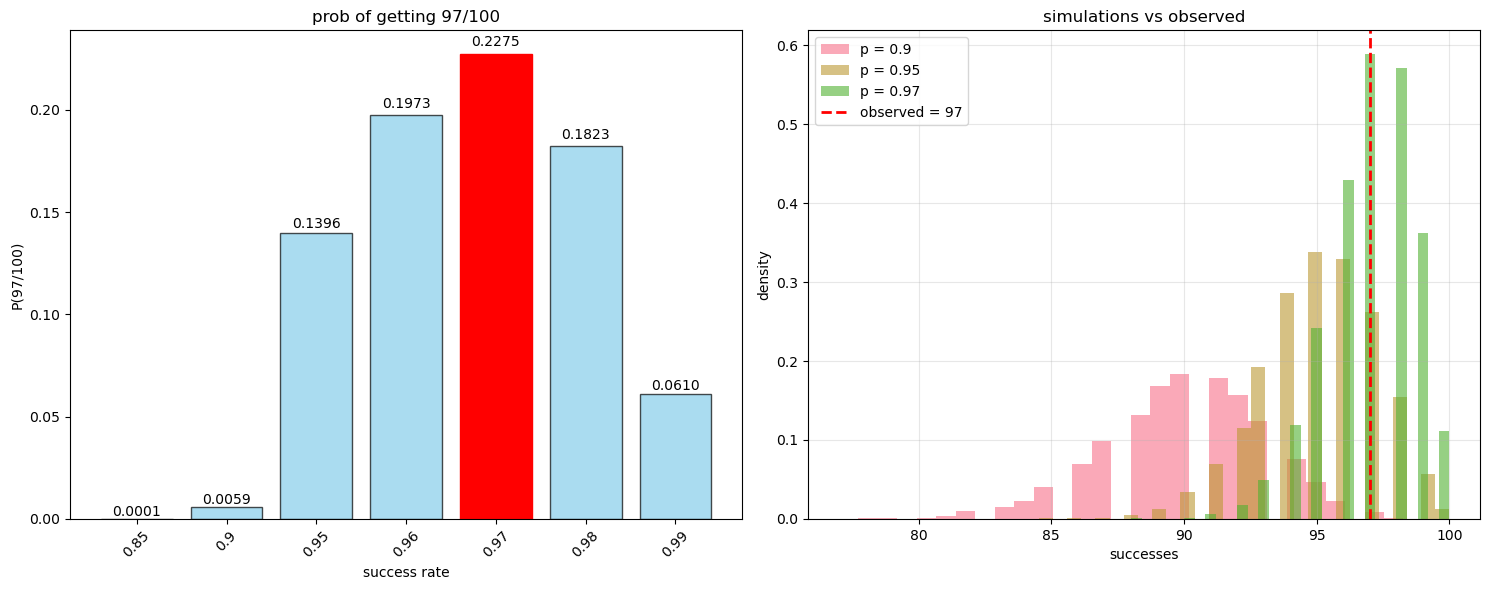


simulation analysis...
p = 0.9: mean = 90.0, std = 3.0, 95% range = [84.0, 95.0]
  → 97 is outside range ✗
p = 0.95: mean = 95.0, std = 2.2, 95% range = [90.0, 99.0]
  → 97 is in range ✓
p = 0.97: mean = 97.0, std = 1.7, 95% range = [93.0, 100.0]
  → 97 is in range ✓


In [8]:
def compare_rates(n_trials=100, observed=97):
    
    print("comparing different success rates...")
    
    # test these rates
    test_rates = [0.85, 0.90, 0.95, 0.96, 0.97, 0.98, 0.99]
    
    print("rate\t\tprob of 97/100\tlog prob")
    print("-" * 40)
    
    for p in test_rates:
        prob = binom.pmf(observed, n_trials, p)
        log_likelihood = binom.logpmf(observed, n_trials, p)
        print(f"{p:.2f}\t\t{prob:.6f}\t\t{log_likelihood:.3f}")
    
    # plot it
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # bars
    probs = [binom.pmf(observed, n_trials, p) for p in test_rates]
    bars = ax1.bar([str(p) for p in test_rates], probs, color='skyblue', alpha=0.7, edgecolor='black')
    
    # highlight max
    max_idx = np.argmax(probs)
    bars[max_idx].set_color('red')
    bars[max_idx].set_alpha(1.0)
    
    ax1.set_xlabel('success rate')
    ax1.set_ylabel('P(97/100)')
    ax1.set_title('prob of getting 97/100')
    ax1.tick_params(axis='x', rotation=45)
    
    # add labels
    for bar, prob in zip(bars, probs):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{prob:.4f}', ha='center', va='bottom', fontsize=10)
    
    # simulation
    n_simulations = 10000
    simulation_results = {}
    
    for p in [0.90, 0.95, 0.97]:
        simulated_successes = np.random.binomial(n_trials, p, n_simulations)
        simulation_results[p] = simulated_successes
    
    # plot sims
    for i, (p, results) in enumerate(simulation_results.items()):
        ax2.hist(results, bins=30, alpha=0.6, label=f'p = {p}', density=True)
    
    ax2.axvline(observed, color='red', linestyle='--', linewidth=2, label=f'observed = {observed}')
    ax2.set_xlabel('successes')
    ax2.set_ylabel('density')
    ax2.set_title('simulations vs observed')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # check which distribution fits best
    print("\nsimulation analysis...")
    for p, results in simulation_results.items():
        mean_sim = np.mean(results)
        std_sim = np.std(results)
        percentile = np.percentile(results, [2.5, 97.5])
        print(f"p = {p}: mean = {mean_sim:.1f}, std = {std_sim:.1f}, 95% range = [{percentile[0]:.1f}, {percentile[1]:.1f}]")
        
        # check if observed fits
        if percentile[0] <= observed <= percentile[1]:
            print(f"  → {observed} is in range ✓")
        else:
            print(f"  → {observed} is outside range ✗")

compare_rates()